In [30]:
#下载函数
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import BertModel, BertTokenizer,BertConfig
from sklearn.metrics import confusion_matrix, classification_report
from transformers import BertTokenizer, BertConfig, Trainer, TrainingArguments
from transformers import BertForSequenceClassification
import numpy as np
import evaluate
import torch
import torch.nn as nn
import math
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
import torch.nn.functional as F

# 加载数据库（Olid or White supremacist）

### White Supremacist数据库

In [42]:
import os, glob
import pandas as pd
from datasets import Dataset, Value

ROOT = os.path.expanduser("~/test/hate-speech-dataset-master")
ALL_DIR  = os.path.join(ROOT, "all_files")
TEST_DIR = os.path.join(ROOT, "sampled_test")
CSV_PATH = os.path.join(ROOT, "annotations_metadata.csv")  # ←改成你真实文件名

# 1) 读标注表
df = pd.read_csv(CSV_PATH)

# 自动找到 label 列（优先叫 label；否则用最后一列）
label_col = "label" if "label" in df.columns else df.columns[-1]

# 统一类型
df["file_id"] = df["file_id"].astype(str)
df[label_col] = df[label_col].astype(str)

# 2) label -> int（0/1）
label_map = {"noHate": 0, "hate": 1}
df["label"] = df[label_col].map(label_map)

# 丢掉没映射成功的行（比如有空值/拼写不同）
df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype("int64")

# 3) 读文本：每个 file_id 对应 all_files/file_id.txt
def read_txt(file_id: str) -> str:
    path = os.path.join(ALL_DIR, f"{file_id}.txt")
    if not os.path.exists(path):
        return ""
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        return f.read().strip()

df["tweet"] = df["file_id"].apply(read_txt)
df = df[df["tweet"].str.len() > 0].reset_index(drop=True)

# 4) 用 sampled_test 里的文件名做 test split
test_stems = set(os.path.splitext(os.path.basename(p))[0]
                 for p in glob.glob(os.path.join(TEST_DIR, "*.txt")))

is_test = df["file_id"].isin(test_stems)
train_df = df[~is_test][["tweet", "label"]].reset_index(drop=True)
test_df  = df[ is_test][["tweet", "label"]].reset_index(drop=True)

# 5) 转 HF Dataset，并强制 label 为 int64（避免 CE loss 报错）
train_dataset = Dataset.from_pandas(train_df, preserve_index=False).cast_column("label", Value("int64"))
test_dataset  = Dataset.from_pandas(test_df,  preserve_index=False).cast_column("label", Value("int64"))

print("train label counts:", train_df["label"].value_counts().to_dict())
print("test  label counts:", test_df["label"].value_counts().to_dict())
print(train_dataset, test_dataset)


Casting the dataset: 100%|██████████| 478/478 [00:00<00:00, 257365.51 examples/s]

train label counts: {0: 9268, 1: 957}
test  label counts: {1: 239, 0: 239}
Dataset({
    features: ['tweet', 'label'],
    num_rows: 10225
}) Dataset({
    features: ['tweet', 'label'],
    num_rows: 478
})


### Olid数据集

In [26]:
###### 数据处理 训练集和测试集分类
label_map = {
    "NOT":0,
    "OFF":1
}
# 读取 CSV
# olid-training中只有13000件推文
df = pd.read_csv('olid-training-v1.0.tsv',sep='\t',usecols=["tweet","subtask_a"])
df.rename(columns={"subtask_a":"label"},inplace=True)
df["label"] = df["label"].map(label_map)

# 打乱
df = df.sample(frac=1).reset_index(drop=True)
# 拆分训练集和测试集.testsize 0.2
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

from datasets import Dataset
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

### （Test）输出当前数据集

In [43]:
train_dataset[:10]


{'tweet': ['As of March 13th , 2014 , the booklet had been downloaded over 18,300 times and counting .',
  'In order to help increase the booklets downloads , it would be great if all Stormfronters who had YouTube accounts , could display the following text in the description boxes of their uploaded YouTube videos .',
  '( Simply copy and paste the following text into your YouTube videos description boxes. )',
  'Click below for a FREE download of a colorfully illustrated 132 page e-book on the Zionist-engineered INTENTIONAL destruction of Western civilization .',
  "Click on the `` DOWNLOAD ( 7.42 MB ) '' green banner link .",
  'Booklet updated on Feb. 14th , 2014 .',
  '( Now with over 18,300 Downloads. )',
  "PDF file : http://www.mediafire.com/download/7p3p3goadvvqvsf/WNDebateBooklet_2-14-14.pdfMSWordfile:http://www.mediafire.com/download/psezkkk4d6a3wt1/WNDebateBooklet _ 2-14-14.docx Watch the 10 hour video version of `` The Zionist Attack on Western Civilization '' @ http://trut

### Tokenizer

In [44]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def tokenize_function(example):
    return tokenizer(example["tweet"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)



# 重命名 label 列为 labels
train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")
#train_dataset = train_dataset.remove_columns(["tweet"])
#test_dataset = test_dataset.remove_columns(["tweet"])
train_dataset.set_format("torch")
test_dataset.set_format("torch")
# print(train_dataset[0])

/home/fang/venv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Map: 100%|██████████| 478/478 [00:00<00:00, 2600.61 examples/s]


# 训练模型（设置参数）

In [45]:
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# 这里直接用你指定的 baseline
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

max_length = 128  # 最长输入token长度

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # 兼容 tuple/list 的情况：
    if isinstance(logits, (tuple, list)):
        logits = logits[0]   # (N, 2)

    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average="binary")  # OFF=1 当正类

    return {
        "accuracy": acc,
        "f1": f1,
    }




In [46]:
baseline_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,   # NOT / OFF
)

# baseline 不需要注意力输出
baseline_model.config.output_attentions = False

training_args = TrainingArguments(
    output_dir="./bert_baseline_olid",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,

    evaluation_strategy="epoch",   # 每个 epoch 结束在 test_enc_dataset 上 eval 一次
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_steps=50,
    logging_dir="./bert_baseline_olid/logs",
    report_to="none",              # 不用 wandb / tensorboard 的话就关掉
)

baseline_trainer = Trainer(
    model=baseline_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,     # 直接用 test 作为 eval
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/fang/venv/lib/python3.12/site-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


In [47]:

baseline_trainer.train()
baseline_model = baseline_trainer.model
print("Final evaluation on test_dataset (baseline BERT)...")
test_metrics = baseline_trainer.evaluate(test_dataset)
print(test_metrics)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.188300,0.667957,0.702929,0.594286
2,0.135100,0.609896,0.755230,0.692913
3,0.080800,0.801774,0.736402,0.663102


Final evaluation on test_dataset (baseline BERT)...


{'eval_loss': 0.6098961234092712, 'eval_accuracy': 0.7552301255230126, 'eval_f1': 0.6929133858267716, 'eval_runtime': 9.8932, 'eval_samples_per_second': 48.316, 'eval_steps_per_second': 0.404, 'epoch': 3.0}


# 保存训练后的模型（注意改后缀！！！！）

In [48]:
# baseline

baseline_trainer.save_model("models/bert_baseline_WS")

In [49]:
tokenizer = AutoTokenizer.from_pretrained("models/bert_baseline_WS")
baseline_model = AutoModelForSequenceClassification.from_pretrained(
    "models/bert_baseline_WS"
)

### 导出错误分类数据

In [50]:
import numpy as np
import pandas as pd

# 1) 预测：返回 logits
pred = baseline_trainer.predict(test_dataset)
logits = pred.predictions                      # shape [N, num_labels]
y_pred = np.argmax(logits, axis=-1)            # 预测类别
y_true = pred.label_ids                        # 真实类别（Trainer从labels拿）

# 2) 找错分位置
wrong_idx = np.where(y_pred != y_true)[0]
print("Wrong count:", len(wrong_idx), "/", len(y_true))


Wrong count: 117 / 478


In [51]:
# 取预测置信度（softmax 后取预测类概率）
from scipy.special import softmax
probs = softmax(logits, axis=-1)
conf = probs[np.arange(len(y_pred)), y_pred]

# 从 dataset 里把字段取出来（尽量兼容）
# 真实标签列通常叫 labels；文本列叫 tweet（如果你没 remove）
text_col = "tweet" if "tweet" in test_dataset.column_names else None

rows = []
for i in wrong_idx:
    ex = test_dataset[int(i)]
    rows.append({
        "index": int(i),
        "text": ex[text_col] if text_col else "",
        "y_true": int(y_true[i]),
        "y_pred": int(y_pred[i]),
        "conf": float(conf[i]),
        "prob_0": float(probs[i, 0]) if probs.shape[1] > 0 else None,
        "prob_1": float(probs[i, 1]) if probs.shape[1] > 1 else None,
        "input_len": int(ex["attention_mask"].sum()) if "attention_mask" in ex else None,
    })

wrong_df = pd.DataFrame(rows)

# 保存 CSV
wrong_df.to_csv("wrong_baseline_WS.csv", index=False)
print("Saved: wrong_baseline_WS.csv")


Saved: wrong_baseline_WS.csv


### 绘制confusion matrix（并且算出accuracy和f1）

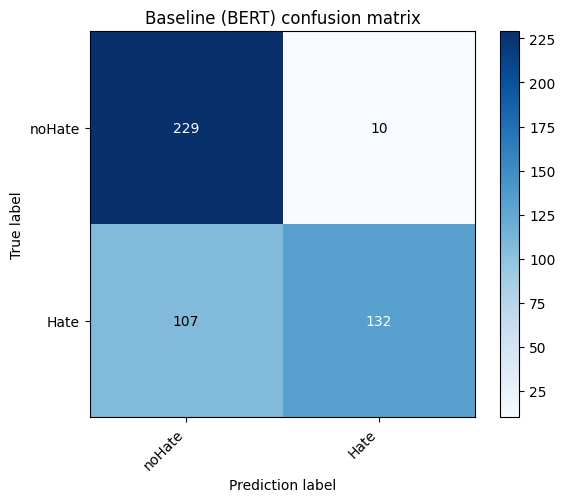

Accuracy : 0.7552301255230126
Macro-F1 : 0.7447175624786032
CM (rows=true, cols=pred):
 [[229  10]
 [107 132]]


In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

def eval_binary_and_plot_cm(trainer, eval_dataset, label_ids=(0, 1), label_names=("NOT", "OFF"),
                            title="Confusion matrix"):
    pred_out = trainer.predict(eval_dataset)
    logits = pred_out.predictions
    if isinstance(logits, tuple):
        logits = logits[0]

    y_pred = np.argmax(logits, axis=-1)
    y_true = pred_out.label_ids

    # 指标
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    # 混淆矩阵（行=真实，列=预测）
    cm = confusion_matrix(y_true, y_pred, labels=list(label_ids))

    # 画图
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()

    ticks = np.arange(len(label_ids))
    plt.xticks(ticks, label_names, rotation=45, ha="right")
    plt.yticks(ticks, label_names)
    plt.ylabel("True label")
    plt.xlabel("Prediction label")

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()

    print("Accuracy :", acc)
    print("Macro-F1 :", macro_f1)
    print("CM (rows=true, cols=pred):\n", cm)

    return {"accuracy": acc, "macro_f1": macro_f1, "confusion_matrix": cm}

# 用法：默认假设 0=NOT, 1=OFF
metrics = eval_binary_and_plot_cm(
    baseline_trainer,
    test_dataset,
    label_ids=(0, 1),
    label_names=("noHate", "Hate"),
    title="Baseline (BERT) confusion matrix"
)
